# Numerical Simulation Laboratory - Exercise 10

## INTRODUCTION

### Travelling Salesman Problem and genetic algorithm

The system considered in this notebook is again the **Travelling Salesman Problem** (TSP), already studied in **Exercise 09**, formulated as an optimization problem in which the objective is to determine the shortest closed path visiting each city exactly once. A candidate solution is represented by a permutation of the cities, and the corresponding cost is the total length of the tour.

The genetic algorithm follows the same structure previously introduced for the TSP: a population of admissible paths is evolved through selection, crossover and mutation operators. The main new element of the present exercise is the **parallel implementation** of this procedure. Multiple populations are evolved simultaneously on different MPI processes and periodically communicate through migration events, in which the best individuals are exchanged.

### Parallel computation

Many numerical problems require a very large number of operations. Parallel computation addresses this issue by distributing the work among several processing units. The ideal goal is to reduce the computation time, or equivalently to solve larger problems with the same available time.

In practice, the efficiency of a parallel implementation depends on the balance between computation and communication. The workload should be distributed as uniformly as possible among the processes. At the same time, communication and synchronization should be kept under control, since they introduce overhead: during these operations, part of the execution time is spent exchanging data or waiting for other processes rather than performing the actual computation.

For stochastic optimization algorithms such as genetic algorithms, a natural parallel strategy is to let different populations explore the search space independently for several generations and to allow them to exchange information only periodically through **migration** events.

### Parallel architectures

Parallel machines can be organized in different ways. In a **shared-memory** architecture, several processors can access the same memory space. In a **distributed-memory** architecture, each process owns its local memory and data must be exchanged explicitly through messages. Many modern systems are hybrid: several cores may share memory inside the same node, while different nodes communicate through a network.

The present implementation is naturally described in the distributed-memory picture. Each MPI process owns its own population, its own random number stream and its own local variables. One process cannot directly modify the population stored by another process: information is transferred only through explicit MPI communications.

### Parallel programming models

Different parallel programming models describe how instructions and data are distributed among processing units.

In the **SISD** model, Single Instruction Single Data, there is only one processor executing one program on one set of data. This is the standard sequential case.

In the **SIMD** model, Single Instruction Multiple Data, the same operation is performed at the same time on many data elements. This is the idea used, for example, in GPUs, where many similar operations can be executed in parallel.

In the **MIMD** model, Multiple Instruction Multiple Data, different processors can execute different instructions on different data. This is a more general model for parallel machines.

A particularly useful MIMD programming style is **SPMD**, **Single Program Multiple Data**. In this case all processes execute the same program, but each process works on different data and can follow different branches depending on its rank. The code used here follows this idea: all MPI processes run the same executable, but each rank evolves a different population of TSP paths.

### Speed-up, efficiency and parallel overhead

The performance of a parallel program can be described through the **speed-up**

$$
S_p = \frac{T_1}{T_p},
$$

where $T_1$ is the execution time on one processor and $T_p$ is the execution time on $p$ processors. The corresponding **efficiency** is

$$
E_p = \frac{S_p}{p}.
$$

In the ideal case, $S_p \simeq p$ and $E_p \simeq 1$. In real programs the speed-up is limited by sequential parts of the code, communication overhead, synchronization and possible workload imbalance.

A useful estimate of this limitation is given by Amdahl's law. If a fraction $f$ of the program can be parallelized, the ideal speed-up is

$$
S_p = \frac{T_1}{T_p}
    = \frac{p}{f+(1-f)p}
    = \frac{1}{f/p+(1-f)}
    \quad \Longrightarrow \quad
    \boldsymbol{S_p \leq \frac{1}{1-f}}.
$$

Here $f$ is the parallelizable fraction of the code, while $(1-f)$ is the sequential fraction. Therefore, increasing the number of processors is useful only if the parallel part dominates and the communication cost remains sufficiently small.

### MPI

MPI, **Message Passing Interface**, is a standard interface used to write parallel programs based on message exchange. In this exercise, MPI is used to run several genetic algorithm populations in parallel and to let them communicate through migration events.

When a program is launched with several MPI processes, MPI automatically creates a default communicator called `MPI_COMM_WORLD`, which contains all the ranks of the run.

Each process is identified by its `rank`, while `size` is the total number of processes in the communicator. For example, the command

```bash
mpirun -np 8 ./Exercise_10.2_parallel.exe
```

starts eight MPI processes running the same executable. The option `-np 8` specifies the number of MPI processes to launch; depending on the machine, these processes can run on different cores. If fewer physical cores are available than the number of launched processes, some cores have to run more than one MPI process, so the program still runs but the parallel efficiency can decrease. In this case, `size = 8` and the ranks are numbered from `0` to `7`.

The value of `rank` allows the same C++ code to perform rank-dependent operations, such as writing different output files or assigning different random streams.

### Migration and MPI commands used

In this exercise, a **migration event** is the moment in which the MPI ranks interrupt their independent evolution and exchange the best paths found so far between their populations. This exchange requires two different types of MPI communication. First, all ranks must know the same communication pattern, namely which rank sends to which other rank. This is done with a collective communication. Then, the actual paths are exchanged through point-to-point communications between pairs of ranks.

A point-to-point communication consists of a sender and a receiver. In a **blocking** call, the rank remains at that call until the required communication condition is satisfied. This is useful when the program cannot safely continue before the data are available or before the communication has reached the required state.

In a **non-blocking** call, the communication is only started, and the rank can continue executing the program while the operation progresses. This is useful when the program can perform other work, or post other communications, before the first operation is completed.

Since a non-blocking communication may still be in progress, a function such as `MPI_Wait` is later used when the program reaches a point where it must be sure that the operation has actually finished.

The following table summarizes the MPI functions, objects and datatypes used in the implementation.

| MPI function/object | Role in the code |
| --- | --- |
| `MPI_Init` | Initializes the MPI environment. |
| `MPI_Finalize` | Terminates the MPI environment. |
| `MPI_COMM_WORLD` | Default communicator that includes all MPI processes started by `mpirun`. |
| `MPI_Comm_size` | Gives the number of MPI processes in the communicator. |
| `MPI_Comm_rank` | Gives the rank of the current process. |
| `MPI_Bcast` | Broadcasts the migration pattern chosen by rank 0 to all ranks. |
| `MPI_Isend` | Starts sending the best path to another rank without blocking immediately. |
| `MPI_Recv` | Receives the best path sent by another rank and blocks until it arrives. |
| `MPI_Wait` | Ensures that the non-blocking send has been completed. |
| `MPI_INT` | MPI datatype used to send and receive arrays of C++ integers. |
| `MPI_Request` | Object used to identify and later complete a non-blocking communication. |

<br>

In this implementation, `MPI_Bcast` is used for the collective sharing of the migration pattern, while `MPI_Isend`, `MPI_Recv` and `MPI_Wait` are used for the point-to-point exchange of paths. The detailed sequence used in the migration routine is discussed in the C++ implementation section.

### Other MPI commands

| MPI command | Meaning |
| --- | --- |
| `MPI_Send` | Blocking point-to-point send. |
| `MPI_Irecv` | Non-blocking point-to-point receive. |
| `MPI_Gather` | Collects data from all ranks onto one chosen rank, called the root. |
| `MPI_Reduce` | Combines values from all ranks through an operation such as sum, product, minimum or maximum, and stores the result on one chosen rank, called the root. |
| `MPI_Wtime` | Measures the wall-clock time of an MPI program. |

These routines are not all used in the present implementation, but they are common tools in MPI programs.

### Parallel genetic algorithm with migrations

The parallel genetic algorithm is organized using several populations, one for each MPI rank. These populations can be interpreted as different **continents**. Between two migration events, each continent evolves independently by applying the genetic algorithm operators to its own population.

After a fixed number of generations, the continents exchange their best individuals. In this way, a good path found by one rank can be introduced into another population. This mechanism increases the exchange of genetic information and can help the algorithm escape local minima. 

## EXERCISE 10.1

### Assignment prompt

Parallelize with MPI libraries your Genetic Algorithm code in order to solve the TSP by performing a *Genetic Search* with (up to) 11 **parallel GA searches of the optimal path**:
each node should perform an independent GA search, the so-called *Continent*, **but** every $N_{migr}$ generations the *Continents* should exchange their best individuals randomly.

### Method

The genetic algorithm is parallelized using MPI. In this first exercise, the code is applied to the TSP with $34$ cities randomly placed inside a square, using one independent population on each MPI rank.

The main parameters of the run are:

- number of cities: $34$;
- number of MPI processes: $8$;
- population size on each rank: $1000$ individuals;
- number of generations: $1000$;
- selection power: $p=2.0$;
- migration frequency: one migration event every $100$ generations;
- crossover probability: $P_c=0.80$;
- mutation probabilities: $0.10$ for swap, shift, block-swap and inversion mutations.

### How to run

The program must be compiled and launched from the `Exercise_10.1` directory:

```bash
cd Exercise_10.1
make
mkdir -p OUTPUT
mpirun -np 8 ./Exercise_10.1.exe
```

Here `-np 8` means that MPI launches eight processes. Each process executes the same program, but with a different value of `rank`. The output files are rank-dependent, for example `losses_parallel_rank_0.dat`, `losses_parallel_rank_1.dat`, and so on.

### C++ implementation: MPI parallelization


The genetic operators used between two migrations are the same as in **Exercise 09**. For this reason, the C++ code blocks reported here focus on the parts that are specific to the parallel implementation: MPI initialization, rank-dependent random streams, independent evolution on each rank, rank-dependent output files, and migration of the best paths.


#### **MPI initialization and independent random streams**


The program is written in the SPMD form: all MPI processes run the same executable. The first MPI calls initialize the parallel environment and assign to each process its own identity, `rank`, together with the total number of processes, `size`.

```cpp
MPI_Init(&argc, &argv); // Initializes MPI using command-line arguments

int rank;
int size;

MPI_Comm_rank(MPI_COMM_WORLD, &rank);  // Gets this MPI process rank and stores it in rank
MPI_Comm_size(MPI_COMM_WORLD, &size);  // Gets the total number of MPI processes and stores it in size
```

In the implementation used here, each rank is initialized with its own random stream, so that the populations do not evolve identically.

The random generator is initialized from the same `seed.in` file, but with a rank-dependent pair of primes. The relevant difference with respect to the non-parallel version is in the way the file `Primes` is read.
<br>

<div style="display: flex; gap: 24px; align-items: stretch; width: 100%;">

<div style="flex: 0 0 50%; padding-right: 20px; border-right: 2px solid #999;">

<b>MPI version</b>

<pre style="background: transparent; border: none; box-shadow: none; padding: 0; margin-top: 12px; white-space: pre-wrap;"><code style="background: transparent; box-shadow: none; color: #d4d4d4; opacity: 1; font-weight: 400; font-size: 14px; line-height: 1.35;"><span style="color: #569cd6;">void</span> <span style="color: #dcdcaa;">initialize_random</span>(Random &amp;rnd, <span style="color: #569cd6;">int</span> rank) {
    <span style="color: #569cd6;">int</span> seed[<span style="color: #b5cea8;">4</span>];
    <span style="color: #569cd6;">int</span> p1, p2;

    ifstream Primes(<span style="color: #ce9178;">"Primes"</span>);

    <span style="color: #569cd6;">if</span> (Primes.is_open()) {
        <span style="color: #569cd6;">for</span> (<span style="color: #569cd6;">int</span> i = <span style="color: #b5cea8;">0</span>; i &lt;= rank; i++) {
            <span style="color: #569cd6;">if</span> (!(Primes &gt;&gt; p1 &gt;&gt; p2)) {   <span style="color: #6a9955;">// Reads up to the pair associated with this rank</span>
                cerr &lt;&lt; <span style="color: #ce9178;">"PROBLEM: Not enough prime pairs in Primes for rank "</span>
                     &lt;&lt; rank &lt;&lt; endl;
                <span style="color: #569cd6;">break</span>;
            }
        }
    } <span style="color: #569cd6;">else</span> {
        cerr &lt;&lt; <span style="color: #ce9178;">"PROBLEM: Unable to open Primes"</span> &lt;&lt; endl;
    }

    Primes.close();

    ...

    rnd.SetRandom(seed, p1, p2);
}</code></pre>

</div>

<div style="flex: 1; padding-left: 20px;">

<b>Standard version</b>

<pre style="background: transparent; border: none; box-shadow: none; padding: 0; margin-top: 12px; white-space: pre-wrap;"><code style="background: transparent; box-shadow: none; color: #d4d4d4; opacity: 1; font-weight: 400; font-size: 14px; line-height: 1.35;"><span style="color: #569cd6;">void</span> <span style="color: #dcdcaa;">initialize_random</span>(Random &amp;rnd) {
    <span style="color: #569cd6;">int</span> seed[<span style="color: #b5cea8;">4</span>];
    <span style="color: #569cd6;">int</span> p1, p2;

    ifstream Primes(<span style="color: #ce9178;">"Primes"</span>);

    <span style="color: #569cd6;">if</span> (Primes.is_open()) {
        Primes &gt;&gt; p1 &gt;&gt; p2;   <span style="color: #6a9955;">// Reads the first pair of primes</span>
    } <span style="color: #569cd6;">else</span> {
        cerr &lt;&lt; <span style="color: #ce9178;">"PROBLEM: Unable to open Primes"</span> &lt;&lt; endl;
    }

    Primes.close();

    ...

    rnd.SetRandom(seed, p1, p2);
}</code></pre>

</div>

</div>

<br>
In the standard version, the only process reads the first pair of primes. In the MPI version, instead, rank 0 reads the first pair, rank 1 reads the second pair, and so on. Therefore, all ranks use the same `seed.in` file, but the pair of primes used by the random generator is rank-dependent.

This point is essential for the parallel GA. If all ranks used the same random stream, they would tend to generate the same initial populations and the same stochastic evolution. With rank-dependent streams, the ranks explore different regions of the search space.

#### **Independent evolution on each rank**


After MPI initialization, each rank builds and evolves its own population. The local GA evolution is performed independently between two migration events. The population is evaluated and sorted at every generation, so that the current best individual is always stored in `population[0]`.

```cpp
Random rnd;
initialize_random(rnd, rank);

const int migration_frequency = 100;

vector<Individual> population = generate_population(rnd, population_size, number_of_cities);

evaluate_population(population, cities);
sort_population(population);

for (int generation = 1; generation <= number_of_generations; generation++) {
    population = create_next_generation(rnd, population, population_size, number_of_cities, selection_power, crossover_probability,
                                        swap_probability, shift_probability, block_swap_probability, block_inversion_probability);

    evaluate_population(population, cities);
    sort_population(population);

    if (generation % migration_frequency == 0) {
        exchange_best_with_best(rnd,population, cities, number_of_cities, rank, size, generation);
    }

    losses_output << generation << " "
                  << population[0].loss << " "
                  << average_best_half(population) << endl;
}
```

The migration frequency fixes the interval between two exchanges. Here a migration is performed every $100$ generations. The call to `exchange_best_with_best` is placed after `sort_population(population)`, because the migration routine assumes that the best path of the local rank is the **first** element of the sorted population.


#### **Rank-dependent output files**


Since all ranks run at the same time, they must not write on the same output files. The filenames are therefore built using the rank number.

```cpp
string filename_with_rank_and_extension(const string &base, int rank, const string &extension) {
    stringstream ss;
    ss << "OUTPUT/" << base << "_parallel_rank_" << rank << extension;
    return ss.str();
}
```



#### **Migration function: exchange of the best paths**


The central part of the parallel implementation is the **migration routine**. The function `exchange_best_with_best` performs the exchange of the best paths among the MPI ranks. In the present simulations, it is called periodically, with a migration frequency of one exchange every $100$ generations. In the following, the function is split into consecutive parts only to make the explanation clearer; all the code reported in this subsection belongs to the same function.

```c++
void exchange_best_with_best(Random &rnd,
                             vector<Individual> &population,
                             const vector<City> &cities,
                             int number_of_cities,
                             int rank,
                             int size,
                             int generation) {

    if (size <= 1) {
        return;
    }
```

The function receives the random number generator, the local population, the list of cities, the number of cities, and the MPI information needed to identify the current process. If the program is running with only one MPI process, no migration is possible and the function immediately returns.


The exchange implemented here is a **best-path exchange**: each rank sends the best individual of its current population and receives the best individual found by another rank.

Before the paths can be exchanged, all ranks must agree on the communication pattern. This pattern is constructed only by rank 0. **Rank 0** creates a random permutation of the MPI ranks and uses it to define a closed cycle of exchanges. The arrays `send_to` and `receive_from` store this pattern: `send_to[i]` is the rank to which rank `i` sends its best path, while `receive_from[i]` is the rank from which rank `i` receives a path.

```c++
    vector<int> send_to(size);
    vector<int> receive_from(size);

    if (rank == 0) {
        vector<int> permutation(size);

        for (int i = 0; i < size; i++) {
            permutation[i] = i;
        }

        for (int i = 0; i < size - 1; i++) {
            int j = i + int(rnd.Rannyu(0.0, double(size - i)));
            swap(permutation[i], permutation[j]);
        }

        for (int i = 0; i < size; i++) {
            int sender = permutation[i];
            int receiver = permutation[(i + 1) % size];

            send_to[sender] = receiver;
            receive_from[receiver] = sender;
        }
    }
```

The first loop initializes the permutation with the ordered list of ranks. The second loop shuffles this list randomly. The last loop interprets the shuffled permutation as a closed cycle: each rank sends to the next rank in the permutation and receives from the previous one. The modulo operator in `(i + 1) % size` closes the cycle, so that the last rank sends to the first one.

In this way, every rank has exactly one destination and one source, and all populations participate in the migration step.

```c++
    MPI_Bcast(send_to.data(),      // buffer: array to broadcast
              size,                // number of elements in the buffer
              MPI_INT,             // datatype of the elements
              0,                   // root rank: process that sends the data
              MPI_COMM_WORLD);     // communicator containing the MPI ranks

    MPI_Bcast(receive_from.data(), // buffer: array to broadcast
              size,                // number of elements in the buffer
              MPI_INT,             // datatype of the elements
              0,                   // root rank: process that sends the data
              MPI_COMM_WORLD);     // communicator containing the MPI ranks

    int destination = send_to[rank];
    int source = receive_from[rank];
```

Since the communication pattern is created only by rank 0, it must be communicated to all the other ranks. This is done with two calls to `MPI_Bcast`, which broadcast the arrays `send_to` and `receive_from`.


After the broadcast, each rank extracts its own `destination` and `source`. From this point on, every process knows where it has to send its path and from where it has to receive a path.

```c++
    vector<int> send_path = population[0].path;
    vector<int> receive_path(number_of_cities);

    MPI_Request request;

    MPI_Isend(send_path.data(),    // buffer: data to send
              number_of_cities,    // number of integers to send
              MPI_INT,             // datatype of the elements
              destination,         // destination rank
              generation,          // message tag
              MPI_COMM_WORLD,      // communicator containing the MPI ranks
              &request);           // request associated with the non-blocking send

    MPI_Recv(receive_path.data(),  // buffer where the received data are stored
             number_of_cities,     // number of integers to receive
             MPI_INT,              // datatype of the elements
             source,               // source rank
             generation,           // expected message tag
             MPI_COMM_WORLD,       // communicator containing the MPI ranks
             MPI_STATUS_IGNORE);   // status information is not needed

    MPI_Wait(&request,             // request associated with the non-blocking send
             MPI_STATUS_IGNORE);   // status information is not needed
```

The path sent by each rank is `population[0].path`. This is the best path of the local population, because the population is sorted before calling the migration function.

The send operation is started with `MPI_Isend`, a non-blocking send. This avoids forcing all ranks to stop immediately at the send instruction. Each rank then waits for the incoming path with `MPI_Recv`, which is a blocking receive. Finally, `MPI_Wait` is used to ensure that the non-blocking send has actually been completed.

Using a non-blocking send is safer than placing a blocking `MPI_Send` before the receive. If all ranks tried to perform a blocking send at the same time, each process could remain waiting for the destination rank to post the corresponding receive, while that rank is also blocked on its own send. The non-blocking send avoids this possible deadlock pattern: the send operation is started, the process can then post the receive, and `MPI_Wait` is called only afterwards to ensure that the send has completed.

The MPI tag is chosen equal to `generation`. This makes the messages associated with different migration steps distinguishable.

```c++
    population[0].path = receive_path;
    population[0].loss = path_length(population[0], cities);

    if (!check_individual(population[0], number_of_cities)) {
        cerr << "PROBLEM: invalid individual received by rank "
             << rank << " at generation " << generation << endl;
    }

    sort_population(population);
}
```

The received path is inserted in `population[0]`, replacing the previous local best path. Its loss is then recomputed using `path_length`.

The validity check is a safety control: the received path must still be an admissible TSP tour, namely a valid permutation of the cities. In a correct run this condition should always be satisfied, since the path was already valid on the sending rank.

Finally, the population is sorted again. The received path is not assumed to remain the best after insertion: after recomputing its loss, the whole population is reordered by increasing path length.

Overall, the function implements a random cyclic exchange of the best paths among the MPI ranks. The communication pattern changes at each migration event, because rank 0 generates a new random permutation of the processes before broadcasting the corresponding `send_to` and `receive_from` arrays. This allows good paths found by one population to enter another one, while keeping the populations mostly independent between two consecutive migrations.

### Cities randomly placed inside a square

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


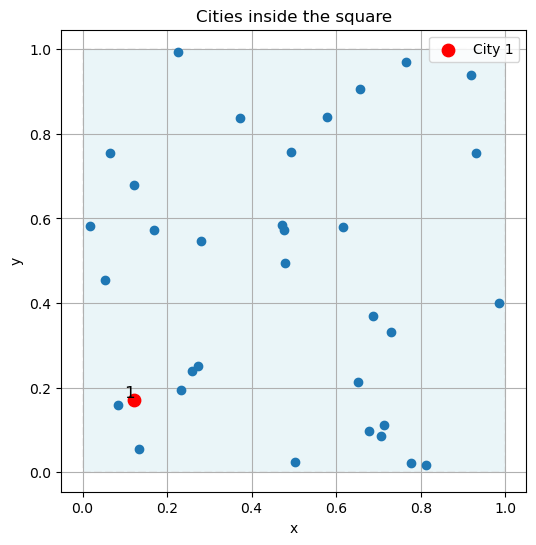

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Columns: city_index, x, y
data = np.loadtxt("Exercise_10.1/cities_square.txt")

city_index = data[:, 0].astype(int)
x = data[:, 1]
y = data[:, 2]

idx_1 = np.where(city_index == 1)[0][0]

plt.figure(figsize=(6, 6))
ax = plt.gca()

square = Rectangle(
    (0, 0),
    1,
    1,
    facecolor="lightblue",
    edgecolor="lightgray",
    linestyle="--",
    linewidth=1.5,
    alpha=0.25,
    zorder=0
)
ax.add_patch(square)

plt.scatter(x, y, zorder=2)
plt.scatter(x[idx_1], y[idx_1], color="red", s=80, label="City 1", zorder=3)

plt.text(
    x[idx_1],
    y[idx_1],
    "1",
    fontsize=12,
    color="black",
    ha="right",
    va="bottom",
    zorder=4
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Cities inside the square")
plt.axis("equal")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.show()

### Best path evolution with parallel GA

rank 0: final best loss = 5.01744, final average best half = 5.25794
rank 1: final best loss = 5.01744, final average best half = 5.37637
rank 2: final best loss = 5.01744, final average best half = 5.32890
rank 3: final best loss = 5.01744, final average best half = 5.29226
rank 4: final best loss = 5.01744, final average best half = 5.43937
rank 5: final best loss = 5.01744, final average best half = 5.33085
rank 6: final best loss = 5.01744, final average best half = 5.35246
rank 7: final best loss = 5.01744, final average best half = 5.28096

Best rank: 0
Best final loss: 5.01744


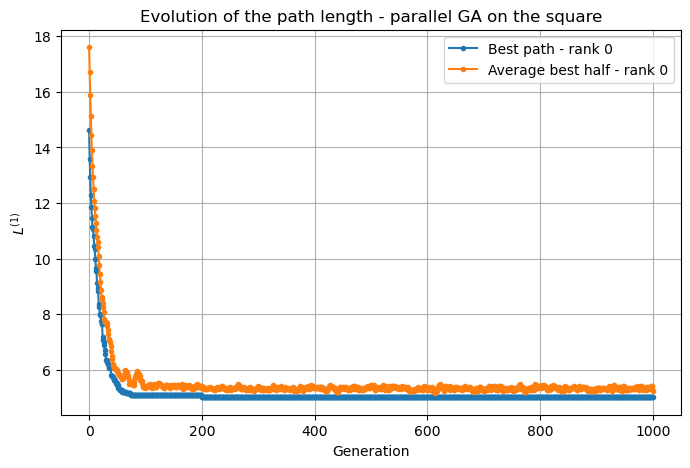

In [7]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

folder = "Exercise_10.1"
output_folder = os.path.join(folder, "OUTPUT")

loss_files = sorted(glob.glob(os.path.join(output_folder, "losses_parallel_rank_*.dat")))

if len(loss_files) == 0:
    raise RuntimeError("No losses_parallel_rank_*.dat files found.")

rank_data = {}
final_losses = []

for loss_file in loss_files:
    rank = int(
        os.path.basename(loss_file)
        .replace("losses_parallel_rank_", "")
        .replace(".dat", "")
    )

    data = np.loadtxt(loss_file)

    if data.ndim == 1:
        data = data.reshape(1, -1)

    rank_data[rank] = data
    final_best_loss = data[-1, 1]
    final_average_best_half = data[-1, 2]
    final_losses.append((rank, final_best_loss, final_average_best_half))

    print(
        f"rank {rank}: final best loss = {final_best_loss:.5f}, "
        f"final average best half = {final_average_best_half:.5f}"
    )

best_rank, best_loss, best_average_best_half = min(final_losses, key=lambda item: (item[1], item[0]))

print()
print(f"Best rank: {best_rank}")
print(f"Best final loss: {best_loss:.5f}")

best_rank_data = rank_data[best_rank]
generation = best_rank_data[:, 0]
best_loss_history = best_rank_data[:, 1]
average_best_half_history = best_rank_data[:, 2]

plt.figure(figsize=(8, 5))
plt.plot(generation, best_loss_history, marker="o", markersize=3, label=f"Best path - rank {best_rank}")
plt.plot(generation, average_best_half_history, marker="o", markersize=3, label=f"Average best half - rank {best_rank}")

plt.xlabel("Generation")
plt.ylabel(r"$L^{(1)}$")
plt.title("Evolution of the path length - parallel GA on the square")
plt.grid(True)
plt.legend()
plt.show()

#### Comment

All MPI ranks reach the same final best path length, $L^{(1)}=5.01744$. This is a typical effect of migration: once a good route appears on one continent, it can be transferred to the other populations at the following exchange steps.

The average over the best half of the population remains slightly larger than the single best path length. This means that, although the best solution has spread among the ranks, each continent still contains a distribution of good but not identical routes.

### Best path found by the parallel GA

Best path length found by the parallel genetic algorithm: 5.01744


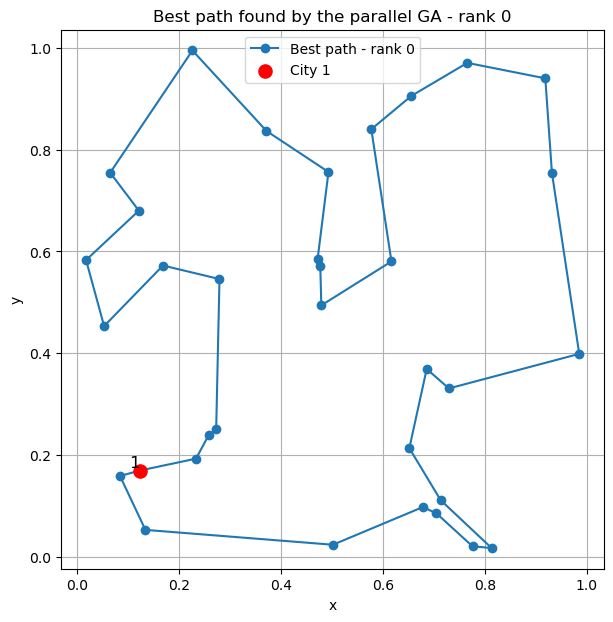

In [8]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

folder = "Exercise_10.1"
output_folder = os.path.join(folder, "OUTPUT")

# Determine the best rank from the final losses. In case of equal losses, choose the smallest rank.
loss_files = sorted(glob.glob(os.path.join(output_folder, "losses_parallel_rank_*.dat")))
final_losses = []

for loss_file in loss_files:
    rank = int(
        os.path.basename(loss_file)
        .replace("losses_parallel_rank_", "")
        .replace(".dat", "")
    )
    data_loss = np.loadtxt(loss_file)
    final_losses.append((rank, data_loss[-1, 1]))

best_rank, best_loss = min(final_losses, key=lambda item: (item[1], item[0]))

# Coordinates: city_index, x, y
cities = np.loadtxt(os.path.join(folder, "cities_square.txt"))
city_index = cities[:, 0].astype(int)
x = cities[:, 1]
y = cities[:, 2]

best_path_file = os.path.join(
    output_folder,
    f"best_path_final_parallel_rank_{best_rank}.txt"
)

best_path = np.loadtxt(best_path_file).astype(int)

city_to_position = {city_id: i for i, city_id in enumerate(city_index)}

path_x = np.array([x[city_to_position[city_id]] for city_id in best_path])
path_y = np.array([y[city_to_position[city_id]] for city_id in best_path])

path_length = np.sum(np.sqrt(np.diff(path_x)**2 + np.diff(path_y)**2))
print(f"Best path length found by the parallel genetic algorithm: {path_length:.5f}")

idx_1 = np.where(city_index == 1)[0][0]

plt.figure(figsize=(7, 7))
plt.plot(path_x, path_y, marker="o", linewidth=1.5, label=f"Best path - rank {best_rank}")
plt.scatter(x[idx_1], y[idx_1], color="red", s=90, zorder=3, label="City 1")

plt.text(
    x[idx_1],
    y[idx_1],
    "1",
    fontsize=12,
    color="black",
    ha="right",
    va="bottom"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Best path found by the parallel GA - rank {best_rank}")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

#### Comment

The final route has no evident large crossings. This is the expected qualitative structure for a good TSP solution: if two edges cross, a local inversion-like move can often untangle them and shorten the route.

As in Exercise 09, the result should be interpreted as the best route found by the stochastic genetic search, not as a formal proof of the global optimum.

## EXERCISE 10.2

### Assignment prompt

Apply your parallel code to the TSP problem for 110 italian "capoluoghi di provincia" longitude and latitude coordinates in the *cap_prov_ita.dat* file.

Do you improve with respect using the same number of computing cores but with **independent GA searches** ?

### Method

The same parallel GA structure is applied to the TSP problem for 110 Italian provincial capitals, using the longitude and latitude coordinates stored in `cap_prov_ita.dat`.

The relevant comparison is between:

- **independent GA searches**, stored in `OUTPUT_SEQUENTIAL`; these runs still use MPI, but the ranks do not communicate with one another;
- **parallel GA with migrations**, stored in `OUTPUT_PARALLEL`; in this case the ranks exchange their best paths every 100 generations.

In the code used here, `Exercise_10.2_sequential.cpp` launches one independent GA population on each MPI rank, while `Exercise_10.2_parallel.cpp` adds migrations between the ranks.

Both runs use 8 MPI processes, population size 1000, 2000 generations, selection power $p=2.0$, crossover probability 0.80 and the same 0.1 mutation probabilities. Therefore, the comparison below directly tests the effect of migrations with all the main genetic algorithm parameters kept fixed.

### How to run

The commands are analogous to Exercise 10.1. The two executables are compiled by the same `Makefile`.

```bash
cd Exercise_10.2
make
mkdir -p OUTPUT_SEQUENTIAL OUTPUT_PARALLEL
mpirun -np 8 ./Exercise_10.2_sequential.exe
mpirun -np 8 ./Exercise_10.2_parallel.exe
```

The first command with `mpirun` produces independent non-migrating populations, while the second one produces communicating populations with migration. Each rank writes its own loss history and final path.

### C++ implementation: independent searches versus migrated searches


The C++ difference between the two programs of Exercise 10.2 is entirely in the communication between MPI ranks.

The file named `Exercise_10.2_sequential.cpp` should be interpreted as a set of **independent non-migrating MPI searches**. It still uses MPI, reads `rank` and `size`, initializes rank-dependent random streams, and writes one output file per rank. However, after initialization the ranks never exchange individuals: they simply run independent GA searches on the same Italian-capitals TSP instance.

The file `Exercise_10.2_parallel.cpp` adds the migration mechanism explained above. The same full function `exchange_best_with_best(...)` is used: every `migration_frequency = 100` generations, the MPI ranks are randomly connected in a cycle and exchange their current best paths.


#### Independent non-migrating MPI program


The independent program still starts as an MPI program.

```c++
MPI_Init(&argc, &argv);

int rank;
int size;

MPI_Comm_rank(MPI_COMM_WORLD, &rank);
MPI_Comm_size(MPI_COMM_WORLD, &size);

Random rnd;
initialize_random(rnd, rank);
```

The important point is that there is no call to `exchange_best_with_best`. Therefore, rank 0, rank 1, ..., rank 7 behave like eight independent attempts to solve the same TSP problem. This gives the reference result for the comparison required by the assignment.


#### Migrated MPI program


The migrated program has the same local GA evolution, but adds one communication step inside the generation loop.

```c++
const int migration_frequency = 100;

if (generation % migration_frequency == 0) {
    exchange_best_with_best(rnd,
                            population,
                            cities,
                            number_of_cities,
                            rank,
                            size,
                            generation);
}
```

This means that the comparison in Exercise 10.2 is not between one serial GA and one parallel GA. It is between:

- several MPI ranks evolving independently, with no exchange of paths;
- several MPI ranks evolving as communicating continents, with periodic best-path migrations.

The second strategy can improve the final route because a good solution discovered on one rank is no longer isolated: after a migration, it becomes available to another population and can be further modified by its independent random evolution.


### Comparison between independent and migrated searches

Independent non-migrating searches:
rank 0: final best loss = 70.0031, final average best half = 73.2365
rank 1: final best loss = 66.4543, final average best half = 68.3434
rank 2: final best loss = 66.7278, final average best half = 70.1649
rank 3: final best loss = 65.2523, final average best half = 68.9981
rank 4: final best loss = 66.0168, final average best half = 68.5996
rank 5: final best loss = 67.3661, final average best half = 69.8405
rank 6: final best loss = 70.2912, final average best half = 73.5322
rank 7: final best loss = 67.6569, final average best half = 70.5667

Parallel GA with migrations:
rank 0: final best loss = 64.9128, final average best half = 67.5471
rank 1: final best loss = 64.9128, final average best half = 66.7918
rank 2: final best loss = 64.9128, final average best half = 68.3996
rank 3: final best loss = 64.9128, final average best half = 68.3927
rank 4: final best loss = 64.9128, final average best half = 67.4945
rank 5: final best loss = 64.9128, fi

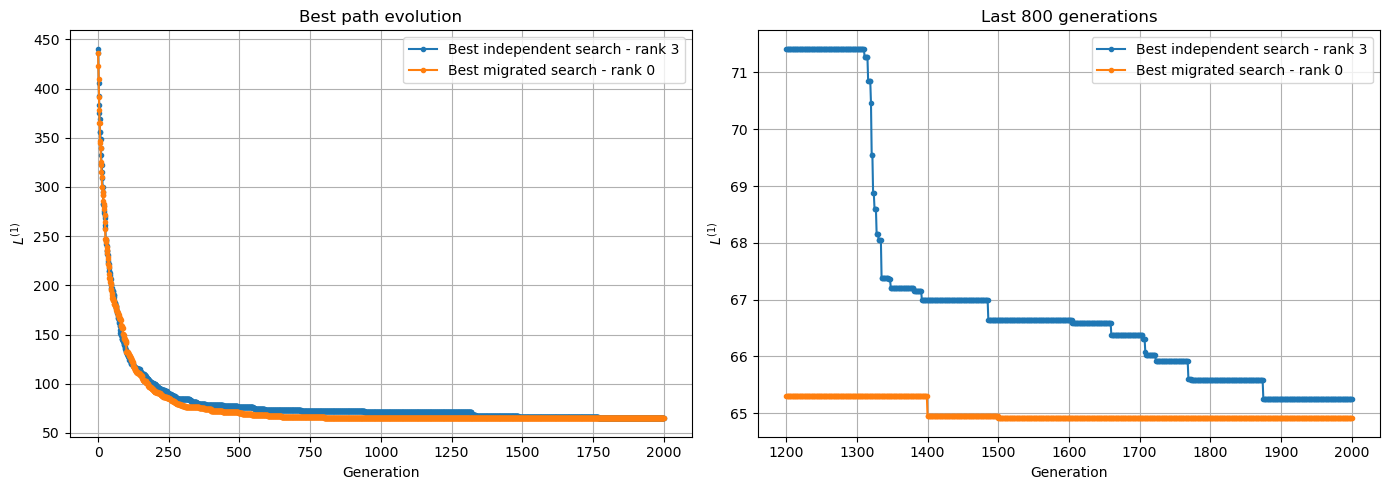

In [9]:
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

folder = "Exercise_10.2"

def load_rank_histories(output_folder, prefix):
    pattern = os.path.join(folder, output_folder, f"losses_{prefix}_rank_*.dat")
    loss_files = sorted(glob.glob(pattern))

    if len(loss_files) == 0:
        raise RuntimeError(f"No files found for pattern {pattern}")

    histories = {}
    final_values = []

    for loss_file in loss_files:
        rank = int(
            os.path.basename(loss_file)
            .replace(f"losses_{prefix}_rank_", "")
            .replace(".dat", "")
        )

        data = np.loadtxt(loss_file)
        histories[rank] = data
        final_values.append((rank, data[-1, 1], data[-1, 2]))

    best_rank, best_loss, best_average_best_half = min(final_values, key=lambda item: (item[1], item[0]))
    return histories, final_values, best_rank, best_loss, best_average_best_half

independent_histories, independent_final, independent_best_rank, independent_best_loss, independent_best_half = load_rank_histories(
    "OUTPUT_SEQUENTIAL",
    "sequential"
)

parallel_histories, parallel_final, parallel_best_rank, parallel_best_loss, parallel_best_half = load_rank_histories(
    "OUTPUT_PARALLEL",
    "parallel"
)

print("Independent non-migrating searches:")
for rank, final_loss, final_average in independent_final:
    print(f"rank {rank}: final best loss = {final_loss:.4f}, final average best half = {final_average:.4f}")

print()
print("Parallel GA with migrations:")
for rank, final_loss, final_average in parallel_final:
    print(f"rank {rank}: final best loss = {final_loss:.4f}, final average best half = {final_average:.4f}")

improvement = (independent_best_loss - parallel_best_loss) / independent_best_loss * 100.0

print()
print(f"Best independent rank: {independent_best_rank}")
print(f"Best independent final loss: {independent_best_loss:.4f}")
print(f"Best migrated rank: {parallel_best_rank}")
print(f"Best migrated final loss: {parallel_best_loss:.4f}")
print(f"Relative improvement of the migrated run: {improvement:.2f}%")

independent_data = independent_histories[independent_best_rank]
parallel_data = parallel_histories[parallel_best_rank]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    independent_data[:, 0],
    independent_data[:, 1],
    marker="o",
    markersize=3,
    label=f"Best independent search - rank {independent_best_rank}"
)
axes[0].plot(
    parallel_data[:, 0],
    parallel_data[:, 1],
    marker="o",
    markersize=3,
    label=f"Best migrated search - rank {parallel_best_rank}"
)

axes[0].set_xlabel("Generation")
axes[0].set_ylabel(r"$L^{(1)}$")
axes[0].set_title("Best path evolution")
axes[0].grid(True)
axes[0].legend()


last_generations = 800
max_generation = min(independent_data[-1, 0], parallel_data[-1, 0])
zoom_start = max_generation - last_generations

independent_zoom = independent_data[independent_data[:, 0] >= zoom_start]
parallel_zoom = parallel_data[parallel_data[:, 0] >= zoom_start]

axes[1].plot(
    independent_zoom[:, 0],
    independent_zoom[:, 1],
    marker="o",
    markersize=3,
    label=f"Best independent search - rank {independent_best_rank}"
)
axes[1].plot(
    parallel_zoom[:, 0],
    parallel_zoom[:, 1],
    marker="o",
    markersize=3,
    label=f"Best migrated search - rank {parallel_best_rank}"
)

axes[1].set_xlabel("Generation")
axes[1].set_ylabel(r"$L^{(1)}$")
axes[1].set_title("Last 800 generations")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Comment

The best independent non-migrating search reaches

$$
L^{(1)}_{\mathrm{independent}} = 65.2523,
$$

while the best migrated run reaches

$$
L^{(1)}_{\mathrm{migrated}} = 64.9128.
$$

The relative improvement is therefore

$$
\frac{65.2523-64.9128}{65.2523}\simeq 0.52\%.
$$

Although this percentage may appear small, it is still significant in this context. The best independent run already finds a very good path, as can also be checked from the final map below, so a further improvement is not expected to be large. Improving an already optimized route by even a small amount is therefore a meaningful result.

The zoom on the last part of the evolution also shows another relevant effect. The migrated run reaches its final value much earlier, approximately $500$ generations before the best independent search. This indicates that, with the same main genetic algorithm parameters, migrations not only improve the final result but also help the search converge faster.

A larger number of generations was also tested. The two runs converged to the same final values reported here, so the analysis was restricted to $2000$ generations.

### Comparison of the best paths

sequential, rank 0: final best loss = 70.0031
sequential, rank 1: final best loss = 66.4543
sequential, rank 2: final best loss = 66.7278
sequential, rank 3: final best loss = 65.2523
sequential, rank 4: final best loss = 66.0168
sequential, rank 5: final best loss = 67.3661
sequential, rank 6: final best loss = 70.2912
sequential, rank 7: final best loss = 67.6569
parallel, rank 0: final best loss = 64.9128
parallel, rank 1: final best loss = 64.9128
parallel, rank 2: final best loss = 64.9128
parallel, rank 3: final best loss = 64.9128
parallel, rank 4: final best loss = 64.9128
parallel, rank 5: final best loss = 64.9128
parallel, rank 6: final best loss = 64.9128
parallel, rank 7: final best loss = 64.9128

Best independent rank: 3
Best independent final loss: 65.2523
Best migrated rank: 0
Best migrated final loss: 64.9128


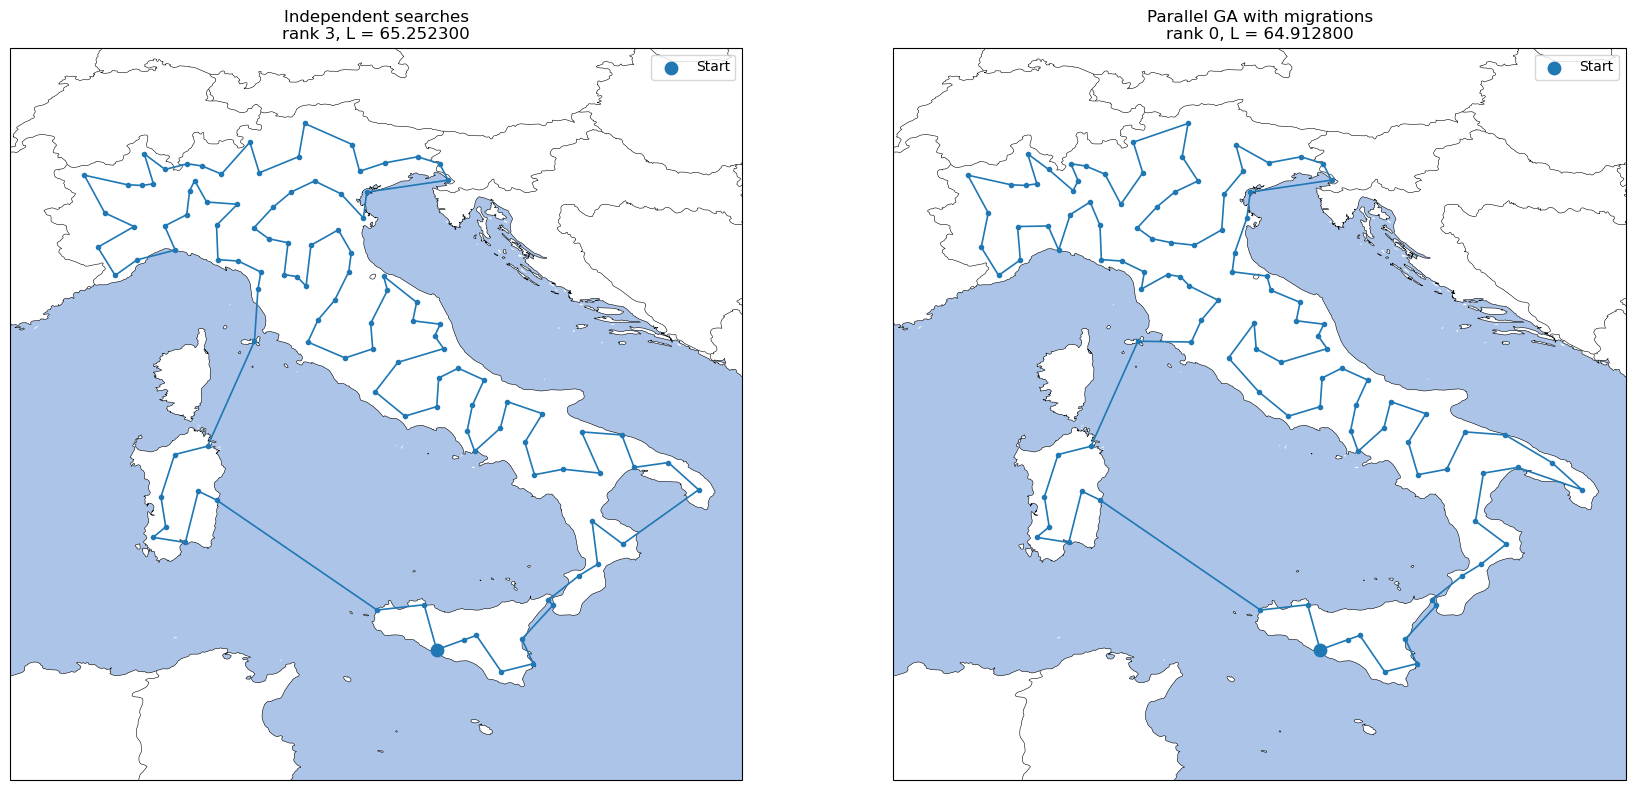

In [10]:
import glob
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import DownloadWarning

warnings.filterwarnings("ignore", category=DownloadWarning)

folder = "Exercise_10.2"

def load_best_path(folder, output_folder, prefix):
    loss_files = sorted(glob.glob(
        os.path.join(folder, output_folder, f"losses_{prefix}_rank_*.dat")
    ))

    if len(loss_files) == 0:
        raise RuntimeError(f"No losses_{prefix}_rank_*.dat files found.")

    best_rank = None
    best_loss = None

    for loss_file in loss_files:
        rank = int(
            os.path.basename(loss_file)
            .replace(f"losses_{prefix}_rank_", "")
            .replace(".dat", "")
        )

        data_loss = np.loadtxt(loss_file)
        final_best_loss = data_loss[-1, 1]

        print(f"{prefix}, rank {rank}: final best loss = {final_best_loss}")

        if best_loss is None or (final_best_loss, rank) < (best_loss, best_rank):
            best_loss = final_best_loss
            best_rank = rank

    best_path_file = os.path.join(
        folder,
        output_folder,
        f"best_path_final_{prefix}_rank_{best_rank}.txt"
    )

    path = np.loadtxt(best_path_file, dtype=int)

    if path[0] == path[-1]:
        path = path[:-1]

    return best_rank, best_loss, path


def path_coordinates(path, cities_file):
    cities = np.loadtxt(cities_file)

    city_id = cities[:, 0].astype(int)
    lon_all = cities[:, 1]
    lat_all = cities[:, 2]

    lon_dict = dict(zip(city_id, lon_all))
    lat_dict = dict(zip(city_id, lat_all))

    lon = np.array([lon_dict[i] for i in path])
    lat = np.array([lat_dict[i] for i in path])

    lon_closed = np.append(lon, lon[0])
    lat_closed = np.append(lat, lat[0])

    return lon, lat, lon_closed, lat_closed


independent_rank, independent_loss, independent_path = load_best_path(
    folder,
    "OUTPUT_SEQUENTIAL",
    "sequential"
)

parallel_rank, parallel_loss, parallel_path = load_best_path(
    folder,
    "OUTPUT_PARALLEL",
    "parallel"
)

print()
print(f"Best independent rank: {independent_rank}")
print(f"Best independent final loss: {independent_loss}")
print(f"Best migrated rank: {parallel_rank}")
print(f"Best migrated final loss: {parallel_loss}")

cities_file = os.path.join(folder, "cap_prov_ita.dat")

ind_lon, ind_lat, ind_lon_closed, ind_lat_closed = path_coordinates(
    independent_path,
    cities_file
)

par_lon, par_lat, par_lon_closed, par_lat_closed = path_coordinates(
    parallel_path,
    cities_file
)

fig = plt.figure(figsize=(18, 8))

ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())

plots = [
    (
        ax1,
        ind_lon,
        ind_lat,
        ind_lon_closed,
        ind_lat_closed,
        f"Independent searches\nrank {independent_rank}, L = {independent_loss:.6f}"
    ),
    (
        ax2,
        par_lon,
        par_lat,
        par_lon_closed,
        par_lat_closed,
        f"Parallel GA with migrations\nrank {parallel_rank}, L = {parallel_loss:.6f}"
    )
]

for ax, lon, lat, lon_closed, lat_closed, title in plots:
    ax.set_extent([6, 19, 35, 48], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, alpha=0)
    ax.add_feature(cfeature.OCEAN, alpha=0.8)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

    ax.plot(
        lon_closed,
        lat_closed,
        "-o",
        markersize=3,
        linewidth=1.2,
        transform=ccrs.PlateCarree()
    )

    ax.scatter(
        lon[0],
        lat[0],
        s=80,
        label="Start",
        transform=ccrs.PlateCarree(),
        zorder=3
    )

    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

#### Comment

The migrated run gives a shorter final path. In the map this corresponds to a slightly more regular connection between the different regions, although the comparison should mainly be based on the final loss values.